In [125]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import pdfplumber
import matplotlib.pyplot as plt
import seaborn as sns

# Project paths and month columns
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "data" / "yearly").exists():
    NOTEBOOK_DIR = Path("/Users/agduyaguit/Documents/PSBA/DHV/finalproject/tourism")

MONTHS = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
PDF_FOLDER = NOTEBOOK_DIR / "data" / "yearly"
OUTPUT_FOLDER = NOTEBOOK_DIR / "output"
PTSA_FILE = NOTEBOOK_DIR / "data" / "2000 to 2025 PTSA Statistical Tables.xlsx"

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)


In [126]:
def normalize_pdf_text(text):
    """
    Normalize PDF text while preserving the spacing between separate numbers.
    This keeps rows like '293,803 276,809' as two values instead of collapsing them.
    """
    text = text.replace('\xa0', ' ')
    text = re.sub(r'[ \t]+', ' ', text)
    return text


In [128]:
# Data cleaning functions
def clean_number(value):
    """
    Convert text numbers into numeric value.
    """
    if value is None:
        return np.nan

    value = str(value).strip()

    if value in ["-", "", "nan", "None"]:
        return np.nan

    value = value.replace(",", "")

    try:
        if "." in value:
            return float(value)
        return int(value)
    except ValueError:
        return np.nan


def normalize_pdf_text(text):
    """
    Normalize PDF text while preserving the spacing between separate numbers.
    """
    text = text.replace("\xa0", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\s+,", ",", text)
    return text


def extract_text_from_pdf(pdf_path):
    """
    Extract text from a PDF file using pdfplumber.
    """
    pages_text = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text(x_tolerance=1, y_tolerance=3) or ""
            normalized_lines = [normalize_pdf_text(line) for line in page_text.splitlines()]
            pages_text.append("\n".join(normalized_lines))

    return "\n".join(pages_text)


def extract_year(text, pdf_path):
    """
    Extract year from PDF text.
    Falls back to filename if needed.
    """

    patterns = [
        r"JANUARY[-\s]+DECEMBER\s+(20\d{2})",
        r"\b(20\d{2})\s+MONTHLY\s+TOTAL\b",
        r"Country of Residence\s+(20\d{2})"
    ]

    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            return int(match.group(1))

    filename_match = re.search(r"(20\d{2})", pdf_path.name)
    if filename_match:
        return int(filename_match.group(1))

    return None


In [129]:
#data extraction functions
def extract_monthly_total_row(text, year):
    """
    Extracts annual/monthly totals from older PDFs (e.g. '2008 MONTHLY TOTAL ...')
    and newer PDFs that use a 'GRAND TOTAL' row for monthly totals.
    """

    lines = text.splitlines()

    for raw_line in lines:
        line = normalize_pdf_text(raw_line).strip()
        if not re.search(rf"{year}\s+MONTHLY\s+TOTAL", line, flags=re.IGNORECASE):
            continue

        row_text = line.split("MONTHLY TOTAL", 1)[1].strip()
        raw_tokens = row_text.split()
        merged_tokens = []
        i = 0

        while i < len(raw_tokens):
            token = raw_tokens[i]
            if re.fullmatch(r"\d", token) and i + 1 < len(raw_tokens):
                next_token = raw_tokens[i + 1]
                if re.fullmatch(r"(?:\d|,)[\d,\.]*", next_token):
                    merged_tokens.append(token + next_token)
                    i += 2
                    continue
            merged_tokens.append(token)
            i += 1

        numbers = [clean_number(token) for token in merged_tokens if re.search(r"\d", token)]

        if len(numbers) < 13:
            return None

        monthly_values = numbers[:12]
        annual_total = numbers[12]
        pct_share = numbers[13] if len(numbers) > 13 else np.nan
        previous_year_total = numbers[14] if len(numbers) > 14 else np.nan
        growth_rate = numbers[15] if len(numbers) > 15 else np.nan

        monthly_record = {
            "year": year,
            **{MONTHS[i]: monthly_values[i] for i in range(12)}
        }

        annual_record = {
            "year": year,
            "visitors_arrivals": annual_total,
            "pct_share": pct_share,
            "previous_year_total": previous_year_total,
            "growth_rate_pct_reported": growth_rate
        }

        return monthly_record, annual_record

    month_name_map = {
        "january": "jan",
        "february": "feb",
        "march": "mar",
        "april": "apr",
        "may": "may",
        "june": "jun",
        "july": "jul",
        "august": "aug",
        "september": "sep",
        "october": "oct",
        "november": "nov",
        "december": "dec",
    }

    for idx, raw_line in enumerate(lines):
        line = normalize_pdf_text(raw_line).strip()
        if not re.search(r"grand total", line, flags=re.IGNORECASE):
            continue

        numbers_text = re.findall(r"-?\d[\d,]*(?:\.\d+)?|-", line)
        numbers = [clean_number(num) for num in numbers_text]

        if len(numbers) < 3:
            continue

        header_line = re.sub(r"[ \t]+", " ", lines[idx - 1] if idx > 0 else "").strip()
        month_labels = re.findall(r"\b(january|february|march|april|may|june|july|august|september|october|november|december)\b", header_line, flags=re.IGNORECASE)
        selected_months = [month_name_map[m.lower()] for m in month_labels] if month_labels else MONTHS[:len(numbers) - 2]

        monthly_values = numbers[:-2]
        annual_total = numbers[-2]
        pct_share = numbers[-1]

        monthly_record = {"year": year}
        for month in MONTHS:
            monthly_record[month] = np.nan

        for month_name, value in zip(selected_months[:12], monthly_values[:12]):
            monthly_record[month_name] = value

        annual_record = {
            "year": year,
            "visitors_arrivals": annual_total,
            "pct_share": pct_share,
            "previous_year_total": np.nan,
            "growth_rate_pct_reported": np.nan,
        }

        return monthly_record, annual_record

    return None


In [131]:
# Region-specific country extraction functions
CONTINENT_HEADINGS = {
    "A S I A": "Asia",
    "A M E R I C A": "America",
    "E U R O P E": "Europe",
    "AUSTRALIA/PACIFIC": "Australia/Pacific"
}

REGION_HEADINGS = {
    "ASEAN": "ASEAN",
    "EAST ASIA": "East Asia",
    "SOUTH ASIA": "South Asia",
    "MIDDLE EAST": "Middle East",
    "NORTH AMERICA": "North America",
    "SOUTH AMERICA": "South America",
    "WESTERN EUROPE": "Western Europe",
    "NORTHERN EUROPE": "Northern Europe",
    "SOUTHERN EUROPE": "Southern Europe",
    "EASTERN EUROPE": "Eastern Europe",
    "EASTERN MEDITERRANEAN EUROPE": "Eastern Mediterranean Europe",
    "AUSTRALIA/PACIFIC": "Australia/Pacific",
    "AFRICA": "Africa",
}

EXCLUDE_MARKET_ROWS = {
    "SUB-TOTAL",
    "TOTAL",
    "TOTAL OVERSEAS FILIPINOS",
    "OVERSEAS FILIPINOS",
    "OTHERS & UNSPECIFIED RESIDENCES",
    "OTHERS UNSPECIFIED RESIDENCES",
    "TOTAL (CIS & RUSSIA)",
    "COMMONWEALTH OF INDEPENDENT STATES",
    "INDEPENDENT STATES"
}

def clean_heading_text(line):
    line = str(line).replace("*", "").strip()
    line = re.sub(r"\s+", " ", line)
    return line.upper()

def clean_country_name(name):
    name = str(name).replace("*", "").strip()
    name = re.sub(r"\s+", " ", name)
    name = name.upper()

    replacements = {
        "KOREA": "South Korea",
        "USA": "United States",
        "HONGKONG": "Hong Kong",
        "RUSSIAN FEDERATION": "Russia",
        "UNITED ARAB EMIRATES": "United Arab Emirates",
        "UNITED KINGDOM": "United Kingdom",
        "NEW ZEALAND": "New Zealand",
        "SOUTH AFRICA": "South Africa",
        "SAUDI ARABIA": "Saudi Arabia",
        "PAPUA NEW GUINEA": "Papua New Guinea",
    }

    return replacements.get(name, name.title())

def is_noise_line(line):
    upper = line.upper()

    noise_keywords = [
        "VISITORS ARRIVALS TO THE PHILIPPINES",
        "COUNTRY OF RESIDENCE",
        "JAN FEB MAR",
        "PAGE ",
        "SOURCES OF DATA",
        "PREPARED BY",
        "MONTHLY GROWTH RATE",
        "TOP 12 MARKETS",
        "RANK COUNTRY",
        "VISIT THE DEPARTMENT",
        "E-MAIL"
    ]

    return any(keyword in upper for keyword in noise_keywords)

def extract_region_market_rows(text, year):
    """
    Extracts country-level visitors arrivals and assigns:
    continent, region, country, monthly values, annual total, share, growth.
    """

    records = []
    current_continent = None
    current_region = None

    for raw_line in text.splitlines():
        line = normalize_pdf_text(raw_line).strip()

        if not line or is_noise_line(line):
            continue

        heading = clean_heading_text(line)

        if heading in CONTINENT_HEADINGS:
            current_continent = CONTINENT_HEADINGS[heading]
            if heading in REGION_HEADINGS:
                current_region = REGION_HEADINGS[heading]
            continue

        if heading in REGION_HEADINGS:
            current_region = REGION_HEADINGS[heading]

            if heading == "AUSTRALIA/PACIFIC":
                current_continent = "Australia/Pacific"

            if heading == "AFRICA":
                current_continent = "Africa"

            continue

        number_match = re.search(r"-?\d{1,3}(?:,\d{3})*(?:\.\d+)|-?\d+(?:\.\d+)?|-", line)
        if not number_match:
            continue

        numbers_text = re.findall(r"-?\d{1,3}(?:,\d{3})*(?:\.\d+)|-?\d+(?:\.\d+)?|-", line)
        if len(numbers_text) < 16:
            continue

        raw_country = line[:number_match.start()].strip()
        country_check = clean_heading_text(raw_country)

        if country_check in EXCLUDE_MARKET_ROWS:
            continue

        if "SUB-TOTAL" in country_check:
            continue

        if "MONTHLY TOTAL" in country_check:
            continue

        values = [clean_number(num) for num in numbers_text]

        monthly_values = values[:12]
        annual_total = values[12]
        share_pct = values[13]
        previous_year_total = values[14]
        growth_rate = values[15]

        records.append({
            "year": year,
            "continent": current_continent,
            "region": current_region,
            "country": clean_country_name(raw_country),
            **{MONTHS[i]: monthly_values[i] for i in range(12)},
            "annual_arrivals": annual_total,
            "share_pct": share_pct,
            "previous_year_arrivals": previous_year_total,
            "growth_rate_pct": growth_rate
        })

    return records


In [132]:
# read all pdf files

annual_records = []
monthly_records = []
market_records = []
failed_files = []

pdf_files = sorted(PDF_FOLDER.glob("*.pdf"))
print(f"Found {len(pdf_files)} PDF files in {PDF_FOLDER}")

for pdf_file in pdf_files:
    try:
        text = extract_text_from_pdf(pdf_file)
        year = extract_year(text, pdf_file)

        if year is None:
            failed_files.append((pdf_file.name, "Could not detect year"))
            continue

        extracted = extract_monthly_total_row(text, year)

        if extracted is None:
            failed_files.append((pdf_file.name, "Could not extract monthly total row"))
            continue

        monthly_record, annual_record = extracted
        monthly_records.append(monthly_record)
        annual_records.append(annual_record)

        market_records.extend(extract_region_market_rows(text, year))

        print(f"Processed {pdf_file.name} for year {year}")

    except Exception as e:
        failed_files.append((pdf_file.name, str(e)))
        print(f"Failed to process {pdf_file.name}: {e}")

if annual_records:
    annual_df = pd.DataFrame(annual_records).sort_values("year")
else:
    annual_df = pd.DataFrame(columns=["year", "visitors_arrivals", "pct_share", "previous_year_total", "growth_rate_pct_reported"])

if monthly_records:
    monthly_df = pd.DataFrame(monthly_records).sort_values("year")
else:
    monthly_df = pd.DataFrame(columns=["year"] + MONTHS)

if market_records:
    market_df = pd.DataFrame(market_records)
else:
    market_df = pd.DataFrame(columns=["year", "continent", "region", "country", "annual_arrivals", "share_pct", "previous_year_arrivals", "growth_rate_pct"] + MONTHS)

failed_df = pd.DataFrame(failed_files, columns=["file", "error"])

display(annual_df.head())
display(monthly_df.head())
display(market_df.head())
display(failed_df.head())

annual_df.to_csv(OUTPUT_FOLDER / "clean_annual_arrivals.csv", index=False)
monthly_df.to_csv(OUTPUT_FOLDER / "clean_monthly_arrivals.csv", index=False)
market_df.to_csv(OUTPUT_FOLDER / "clean_region_country_arrivals.csv", index=False)
failed_df.to_csv(OUTPUT_FOLDER / "failed_files.csv", index=False)

# derived metrics
annual_df = annual_df.sort_values("year").reset_index(drop=True)

annual_df["visitors_arrivals_millions"] = annual_df["visitors_arrivals"] / 1_000_000
annual_df["yoy_growth_pct_calculated"] = annual_df["visitors_arrivals"].pct_change() * 100

if 2019 in annual_df["year"].values:
    arrivals_2019 = annual_df.loc[annual_df["year"] == 2019, "visitors_arrivals"].iloc[0]
    annual_df["recovery_vs_2019_pct"] = annual_df["visitors_arrivals"] / arrivals_2019 * 100
else:
    annual_df["recovery_vs_2019_pct"] = np.nan

monthly_long_df = monthly_df.melt(id_vars=["year"], value_vars=MONTHS, var_name="month", value_name="visitors_arrivals")

monthly_order = {m: i + 1 for i, m in enumerate(MONTHS)}
monthly_long_df["month_num"] = monthly_long_df["month"].map(monthly_order)
monthly_long_df["visitors_arrivals_millions"] = monthly_long_df["visitors_arrivals"] / 1_000_000

# pivot tables
# continent > region > country > year
region_country_multi = (
    market_df
    .set_index(["continent", "region", "country", "year"])
    .sort_index()
)
display(region_country_multi.head(30))

#1. region totals by year
region_year_pivot = pd.pivot_table(
    market_df,
    index="region",
    columns="year",
    values="annual_arrivals",
    aggfunc="sum",
    fill_value=0
)
display(region_year_pivot.head(30))

#2. country contribution within each region
country_region_pivot = pd.pivot_table(
    market_df,
    index=["continent", "region", "country"],
    columns="year",
    values="annual_arrivals",
    aggfunc="sum",
    fill_value=0
)
display(country_region_pivot.head(30))

#3. monthly multiindex columns
monthly_multi_pivot = pd.pivot_table(
    monthly_long_df,
    index="year",
    columns=["month_num", "month"],
    values="visitors_arrivals",
    aggfunc="sum"
)
display(monthly_multi_pivot)

# summary stats
market_summary_multi = (
    market_df
    .groupby(["continent", "region", "country"])
    .agg(
        total_arrivals=("annual_arrivals", "sum"),
        average_annual_arrivals=("annual_arrivals", "mean"),
        best_year_arrivals=("annual_arrivals", "max"),
        worst_year_arrivals=("annual_arrivals", "min"),
        average_share_pct=("share_pct", "mean")
    )
    .sort_values("total_arrivals", ascending=False)
)

display(market_summary_multi.head(20))


Found 16 PDF files in /Users/agduyaguit/Documents/PSBA/DHV/finalproject/tourism/data/yearly
Processed 2008.pdf for year 2008
Processed 2009.pdf for year 2009
Processed 2010.pdf for year 2010
Processed 2011.pdf for year 2011
Processed 2012.pdf for year 2012
Processed 2013.pdf for year 2013
Processed 2014.pdf for year 2014
Processed 2015.pdf for year 2015
Processed 2016.pdf for year 2016
Processed 2017.pdf for year 2017
Processed 2018.pdf for year 2018
Processed 2019.pdf for year 2019
Processed 2020.pdf for year 2020
Processed 2021.pdf for year 2021
Processed 2022.pdf for year 2022
Processed 2023.pdf for year 2023


,year,visitors_arrivals,pct_share,previous_year_total,growth_rate_pct_reported
0,2008,3139422,100.0,3091993.0,1.53
1,2009,3017099,100.0,3139422.0,-3.90
2,2010,3520471,100.0,3017099.0,16.68
3,2011,3917454,100.0,3520471.0,11.28
4,2012,4272811,100.0,3917454.0,9.07


,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
0,2008,293803.0,276809.0,287632.0,253869.0,260567.0,261207.0,285243.0,238012.0,208167.0,241809,231129.0,301175.0
1,2009,286992.0,234198.0,264455.0,261421.0,245060.0,234450.0,261489.0,238724.0,202822.0,226625,248731.0,312132.0
2,2010,298119.0,269081.0,308326.0,277672.0,283537.0,276551.0,325716.0,291582.0,247191.0,267798,281313.0,393585.0
3,2011,349713.0,318912.0,320876.0,317443.0,302707.0,309749.0,360784.0,323491.0,284040.0,298151,337021.0,394567.0
4,2012,411064.0,361925.0,375083.0,349779.0,321930.0,323725.0,376948.0,337894.0,291637.0,328300,352438.0,442088.0


,year,continent,region,country,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,annual_arrivals,share_pct,previous_year_arrivals,growth_rate_pct
0,2008,Asia,ASEAN,Brunei,136.0,2.0,16.0,311.0,2.0,79.0,252.0,413.0,321.0,2.0,28.0,260.0,236.0,324.0,480.0,3.0
1,2008,Asia,ASEAN,Cambodia,113.0,8.0,3.0,129.0,2.0,3.0,112.0,188.0,161.0,1.0,49.0,145.0,228.0,184.0,139.0,1.0
2,2008,Asia,ASEAN,Indonesia,2.0,224.0,2.0,54.0,2.0,326.0,2.0,99.0,2.0,447.0,2.0,650.0,2.0,197.0,2.0,162.0
3,2008,Asia,ASEAN,Laos,63.0,2.0,7.0,70.0,68.0,51.0,79.0,74.0,6.0,9.0,51.0,9.0,7.0,100.0,65.0,814.0
4,2008,Asia,ASEAN,Malaysia,5.0,86.0,6.0,65.0,5.0,824.0,5.0,192.0,5.0,561.0,5.0,492.0,6.0,295.0,6.0,321.0


,file,error


jan    feb    mar    apr    may  \
continent region        country year                                      
America   North America Canada  2008   11.0   17.0    7.0  963.0   10.0   
                                2009   11.0  169.0    7.0  958.0    9.0   
                                2010   11.0  333.0    7.0  542.0   10.0   
                                2011   13.0  712.0    9.0  135.0    1.0   
                                2012   14.0   88.0   10.0  682.0   11.0   
                                2013   14.0  660.0   10.0  678.0   13.0   
                                2014   16.0  413.0   12.0   93.0    1.0   
                                2015   17.0  922.0   13.0  146.0   15.0   
                                2016   21.0  108.0   15.0  665.0   16.0   
                                2017   24.0  352.0   19.0   16.0   17.0   
                                2018    2.0    8.0  913.0   19.0  278.0   
                                2019    2.0    8.0  144.0   22.0  272.0   
                                2020   27.0  929.0   18.0  900.0    6.0   
                                2021    1.0   17.0  275.0    2.0   38.0   
                        Mexico  2008  133.0    1.0    2.0  160.0   98.0   
                                2009  100.0   77.0   88.0  181.0   87.0   
                                2010   95.0   66.0   98.0   92.0   78.0   
                                2011  108.0   78.0  131.0  118.0  139.0   
                                2012  157.0    1.0   20.0  148.0    1.0   
                                2013  204.0  209.0  199.0  234.0  155.0   
                                2014    2.0   36.0  154.0  264.0  218.0   
                                2015  307.0  235.0  267.0    2.0   43.0   
                                2016  285.0  223.0  217.0    2.0   49.0   
                                2017  366.0  309.0  268.0    3.0   62.0   
                                2018  318.0  261.0  403.0    3.0   59.0   
                                2019  412.0    3.0   72.0  407.0  485.0   
                                2020  497.0  265.0  145.0    3.0    1.0   
                                2021    1.0    9.0   12.0    1.0    0.0   
                        Sub     2008    NaN   69.0  636.0   58.0  437.0   
                                2009    NaN   65.0   14.0   54.0  311.0   

                                        jun    jul    aug    sep    oct  \
continent region        country year                                      
America   North America Canada  2008  545.0    7.0  987.0    8.0  432.0   
                                2009  334.0   10.0  789.0    7.0  682.0   
                                2010  169.0    8.0  816.0    9.0  398.0   
                                2011    0.0  953.0   11.0  178.0   10.0   
                                2012  747.0    1.0    1.0  782.0    1.0   
                                2013  148.0   11.0  866.0   10.0  734.0   
                                2014    4.0  333.0   13.0  732.0   11.0   
                                2015  688.0    1.0    3.0  990.0   13.0   
                                2016  528.0    1.0    4.0  987.0    1.0   
                                2017  470.0   19.0  755.0   16.0  794.0   
                                2018    2.0    2.0  310.0   19.0  148.0   
                                2019    2.0    1.0  936.0   22.0  309.0   
                                2020  644.0   17.0    8.0   44.0    9.0   
                                2021    8.0    7.0  213.0  269.0  488.0   
                        Mexico  2008   92.0   93.0  110.0    9.0    5.0   
                                2009   65.0   75.0   85.0    1.0   16.0   
                                2010  105.0   98.0   91.0   87.0  124.0   
                                2011  124.0  108.0   74.0    1.0   53.0   
                                2012   37.0  181.0  105.0  168.0    1.0   
                                2013  197.0  321.0  255.0  211.0

year,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
region,,,,,,,,,,,,,,
ASEAN,1550.0,1595.0,931.0,1202.0,1881.0,378.0,2381.0,3497.0,1954.0,3503.0,1000.0,2687.0,1600.0,576.0
East Asia,363.0,461.0,872.0,180.0,1674.0,433.0,1350.0,3128.0,1519.0,2908.0,1598.0,1637.0,1181.0,1728.0
Eastern Europe,4640.0,1035.0,689.0,334.0,820.0,890.0,1638.0,382.0,423.0,1041.0,1048.0,1507.0,464.0,380.0
Eastern Mediterranean Europe,0.0,3829.0,3640.0,4433.0,5207.0,3551.0,4476.0,5419.0,4599.0,3029.0,3770.0,5793.0,2550.0,2572.0
Middle East,2186.0,3210.0,1510.0,1127.0,1664.0,374.0,1931.0,2121.0,2245.0,1432.0,268.0,2313.0,944.0,249.0
North America,347.0,624.0,341.0,1509.0,904.0,1055.0,1694.0,1335.0,1198.0,2363.0,949.0,1502.0,286.0,62.0
Northern Europe,1579.0,2330.0,2314.0,3245.0,2746.0,1700.0,1738.0,2575.0,2210.0,1465.0,258.0,1616.0,750.0,240.0
South America,469.0,690.0,338.0,756.0,755.0,617.0,1232.0,1240.0,1726.0,1956.0,1096.0,1722.0,471.0,172.0
South Asia,2419.0,1568.0,950.0,2793.0,1559.0,159.0,2124.0,2194.0,2140.0,2426.0,1684.0,3209.0,2222.0,612.0


year                                    2008   2009   2010   2011   2012  \
continent region        country                                            
America   North America Canada           8.0    7.0    7.0  829.0    6.0   
                        Mexico         118.0   85.0    1.0  145.0  199.0   
                        Sub            169.0  530.0  283.0  531.0  644.0   
                        United States   52.0    2.0   50.0    4.0   55.0   
          South America Sub            295.0  345.0  319.0  378.0  538.0   
                        Argentina        2.0   44.0    6.0   61.0    7.0   
                        Brazil         160.0  157.0    1.0  216.0  191.0   
                        Colombia         1.0   56.0    5.0   50.0    8.0   
                        Peru             6.0   47.0    4.0   26.0    2.0   
                        Venezuela        5.0   41.0    3.0   25.0    9.0   
Asia      ASEAN         Sub            545.0  436.0  901.0   44.0  734.0   
                        Brunei         236.0  463.0    4.0  647.0  506.0   
                        Cambodia       228.0  143.0    2.0  193.0  229.0   
                        Indonesia        2.0    2.0    2.0    2.0    2.0   
                        Laos             7.0   67.0    1.0   66.0    5.0   
                        Malaysia         6.0    4.0    6.0    8.0    1.0   
                        Myanmar        515.0  470.0    3.0  237.0  387.0   
                        Singapore        8.0    7.0    9.0    1.0   12.0   
                        Thailand         2.0    2.0    2.0    3.0    3.0   
                        Vietnam          1.0    1.0    1.0    1.0    2.0   
          East Asia     Sub            261.0  421.0  721.0  146.0  584.0   
                        China           12.0   12.0   20.0    8.0   12.0   
                        Hong Kong        9.0   10.0   13.0   10.0  941.0   
                        Japan           28.0    0.0   30.0    5.0   28.0   
                        Macau            0.0    0.0    0.0    0.0   12.0   
                        South Korea     52.0    8.0   72.0    6.0   77.0   
                        Taiwan           1.0   10.0   16.0    5.0   20.0   
          Middle East   Sub            913.0  805.0  575.0   14.0  158.0   
                        Bahrain        308.0  218.0    3.0  303.0  304.0   
                        Egypt            1.0   75.0    1.0  116.0  138.0   

year                                    2013   2014   2015   2016   2017  \
continent region        country                                            
America   North America Canada           9.0  748.0  255.0    9.0  856.0   
                        Mexico           2.0  242.0  215.0  233.0    1.0   
                        Sub            991.0  703.0  692.0  880.0  830.0   
                        United States   53.0    1.0  173.0   76.0  676.0   
          South America Sub            598.0  632.0  620.0  925.0  631.0   
                        Argentina        1.0  145.0  152.0  141.0  290.0   
                        Brazil           3.0  318.0  303.0  415.0  687.0   
                        Colombia         9.0   91.0   85.0  170.0  243.0   
                        Peru             4.0   33.0   61.0   60.0   72.0   
                        Venezuela        2.0   13.0   19.0   15.0   33.0   
Asia      ASEAN         Sub            252.0  967.0  684.0  480.0  665.0   
                        Brunei          87.0   80.0  678.0  523.0  907.0   
                        Cambodia         3.0  405.0  233.0  228.0  384.0   
                        Indonesia        3.0    3.0    4.0    3.0    4.0   
                        Laos             1.0  148.0   96.0   87.0  199.0   
                        Malaysia         8.0    2.0  851.0   11.0  633.0   
                        Myanmar          4.0  765.0  524.0  600.0  683.0   
                        Singapore       14.0    6.0  422.0   16.0   22.0   
                        Thailand         4.0   

month_num,1,2,3,4,5,6,7,8,9,10,11,12
month,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
year,,,,,,,,,,,,
2008,293803.0,276809.0,287632.0,253869.0,260567.0,261207.0,285243.0,238012.0,208167.0,241809.0,231129.0,301175.0
2009,286992.0,234198.0,264455.0,261421.0,245060.0,234450.0,261489.0,238724.0,202822.0,226625.0,248731.0,312132.0
2010,298119.0,269081.0,308326.0,277672.0,283537.0,276551.0,325716.0,291582.0,247191.0,267798.0,281313.0,393585.0
2011,349713.0,318912.0,320876.0,317443.0,302707.0,309749.0,360784.0,323491.0,284040.0,298151.0,337021.0,394567.0
2012,411064.0,361925.0,375083.0,349779.0,321930.0,323725.0,376948.0,337894.0,291637.0,328300.0,352438.0,442088.0
2013,436079.0,418108.0,417392.0,377879.0,362062.0,369073.0,418288.0,382022.0,328114.0,358369.0,361271.0,452650.0
2014,461383.0,422631.0,425858.0,386665.0,364598.0,372293.0,428144.0,405970.0,328981.0,358876.0,390315.0,487654.0
2015,479149.0,456524.0,456163.0,423366.0,413937.0,390486.0,489724.0,480689.0,393589.0,412185.0,411868.0,553002.0


total_arrivals  \
continent region                       country                     
Europe    Eastern Mediterranean Europe Sub               17076.0   
                                                          9434.0   
America   North America                Sub                8024.0   
Asia      South Asia                   Sub                7140.0   
          ASEAN                        Sub                7085.0   
Europe    Eastern Europe               Sub                6864.0   
America   South America                Sub                6543.0   
Asia      East Asia                    Sub                6293.0   
Europe    Northern Europe              Sub                6189.0   
          Western Europe               Sub                6130.0   
Asia      Middle East                  Sub                6037.0   
          ASEAN                        Brunei             5712.0   
Europe    Western Europe               Austria            5592.0   
          Eastern Mediterranean Europe T O T A L          5075.0   
                                       Turkey             4976.0   
          Southern Europe              Sub                4882.0   
          Eastern Europe               Poland             4789.0   
          Northern Europe              Ireland            4601.0   
Asia      Middle East                  Kuwait             4503.0   
          East Asia                    Macau              4407.0   

                                                  average_annual_arrivals  \
continent region                       country                              
Europe    Eastern Mediterranean Europe Sub                     437.846154   
                                                               377.360000   
America   North America                Sub                     573.142857   
Asia      South Asia                   Sub                     510.000000   
          ASEAN                        Sub                     506.071429   
Europe    Eastern Europe               Sub                     429.000000   
America   South America                Sub                     467.357143   
Asia      East Asia                    Sub                     449.500000   
Europe    Northern Europe              Sub                     442.071429   
          Western Europe               Sub                     437.857143   
Asia      Middle East                  Sub                     431.214286   
          ASEAN                        Brunei                  408.000000   
Europe    Western Europe               Austria                 399.428571   
          Eastern Mediterranean Europe T O T A L               390.384615   
                                       Turkey                  382.769231   
          Southern Europe              Sub                     348.714286   
          Eastern Europe               Poland                  342.071429   
          Northern Europe              Ireland                 328.642857   
Asia      Middle East                  Kuwait                  321.642857   
          East Asia                    Macau                   440.700000   

                                                  best_year_arrivals  \
continent region                       country                         
Europe    Eastern Mediterranean Europe Sub                     997.0   
                                                               937.0   
America   North America                Sub                     991.0   
Asia      South Asia                   Sub                     993.0   
          ASEAN                        Sub                     992.0   
Europe    Eastern Europe               Sub                     932.0   
America   South America                Sub                     954.0   
Asia      East Asia                    Sub                     987.0   
Europe    Northern Europe              Sub                     970.0   
          Western Europe               Sub                     925

In [133]:
# top countries
top_country_each_region_year = (
    market_df
    .sort_values(["year", "region", "annual_arrivals"], ascending=[True, True, False])
    .groupby(["year", "continent", "region"], as_index=False)
    .first()
)

top_country_each_region_year = top_country_each_region_year[
    [
        "year",
        "continent",
        "region",
        "country",
        "annual_arrivals",
        "share_pct",
        "growth_rate_pct"
    ]
]

display(top_country_each_region_year)

country_region_total = (
    market_df
    .groupby(["continent", "region", "country"], as_index=False)
    .agg(
        total_arrivals_2008_2023=("annual_arrivals", "sum"),
        average_annual_arrivals=("annual_arrivals", "mean"),
        best_year_arrivals=("annual_arrivals", "max")
    )
)

top_country_each_region_all_year = (
    country_region_total
    .sort_values(["region", "total_arrivals_2008_2023"], ascending=[True, False])
    .groupby(["continent", "region"], as_index=False)
    .first()
)

display(top_country_each_region_all_year)
top_country_each_region_all_year.to_csv(OUTPUT_FOLDER / "top_country_each_region_2008_2023.csv", index=False)

# region share of total arrivals
region_year = (
    market_df
    .groupby(["year", "continent", "region"], as_index=False)
    .agg(region_arrivals=("annual_arrivals", "sum"))
)

annual_total_by_region_data = (
    region_year
    .groupby("year", as_index=False)
    .agg(total_arrivals_from_regions=("region_arrivals", "sum"))
)

region_share_df = region_year.merge(
    annual_total_by_region_data, on="year", how="left"
)

region_share_df["region_share_pct"] = (
    region_share_df["region_arrivals"] / region_share_df["total_arrivals_from_regions"] * 100
)

display(region_share_df.head())

region_share_df.to_csv(OUTPUT_FOLDER / "region_share_of_total_arrivals.csv", index=False)


,year,continent,region,country,annual_arrivals,share_pct,growth_rate_pct
0,2008,America,North America,Sub,169.0,57.0,41.00
1,2008,America,South America,Sub,295.0,3.0,0.11
2,2008,Asia,ASEAN,Sub,545.0,21.0,21.00
3,2008,Asia,East Asia,Sub,261.0,125.0,116.00
4,2008,Asia,Middle East,Sub,913.0,5.0,4.00
...,...,...,...,...,...,...,...
148,2021,Europe,Eastern Europe,Sub,327.0,3.0,2.09
149,2021,Europe,Eastern Mediterranean Europe,Sub,969.0,3.0,2.17
150,2021,Europe,Northern Europe,Sub,107.0,1.0,6.00
151,2021,Europe,Southern Europe,Sub,290.0,3.0,2.00


,continent,region,country,total_arrivals_2008_2023,average_annual_arrivals,best_year_arrivals
0,America,North America,Sub,8024.0,573.142857,991.0
1,America,South America,Sub,6543.0,467.357143,954.0
2,Asia,ASEAN,Sub,7085.0,506.071429,992.0
3,Asia,East Asia,Sub,6293.0,449.500000,987.0
4,Asia,Middle East,Sub,6037.0,431.214286,927.0
5,Asia,South Asia,Sub,7140.0,510.000000,993.0
6,Europe,Eastern Europe,Sub,6864.0,429.000000,932.0
7,Europe,Eastern Mediterranean Europe,Sub,17076.0,437.846154,997.0
8,Europe,Northern Europe,Sub,6189.0,442.071429,970.0
9,Europe,Southern Europe,Sub,4882.0,348.714286,880.0


,year,continent,region,region_arrivals,total_arrivals_from_regions,region_share_pct
0,2008,America,North America,347.0,14898.0,2.329172
1,2008,America,South America,469.0,14898.0,3.148074
2,2008,Asia,ASEAN,1550.0,14898.0,10.404081
3,2008,Asia,East Asia,363.0,14898.0,2.436569
4,2008,Asia,Middle East,2186.0,14898.0,14.673110


In [ ]:
# process ptsa data
try: 
    ptsa_raw = pd.read_excel(PTSA_FILE, sheet_name="Tables 10", header=None)
    ptsa_tdgva = ptsa_raw.iloc[3:29, [0, 1, 2, 3, 4, 5]].copy()

    ptsa_tdgva.columns = [
        "year",
        "tdgva_million_php",
        "tdgva_growth_pct",
        "gdp_million_php",
        "gdp_growth_pct",
        "tdgva_share_to_gdp_pct"
    ]

    ptsa_tdgva = ptsa_tdgva.dropna(subset=["year"])
    ptsa_tdgva["year"] = ptsa_tdgva["year"].astype(int)

    numeric_cols = [
        "tdgva_million_php",
        "tdgva_growth_pct",
        "gdp_million_php",
        "gdp_growth_pct",
        "tdgva_share_to_gdp_pct"
    ]

    for col in numeric_cols:
        ptsa_tdgva[col] = pd.to_numeric(ptsa_tdgva[col], errors="coerce")
    
    ptsa_tdgva = ptsa_tdgva[ptsa_tdgva["year"].between(2008, 2023)]

    display(ptsa_tdgva.head())

    ptsa_tdgva.to_csv(OUTPUT_FOLDER / "clean_ptsa_tdgva_gdp_csv", index=False)

except Exception as e:
    print("Could not read PTSA Table 10: ", e)
    ptsa_tdgva = pd.DataFrame()

,year,tdgva_million_php,tdgva_growth_pct,gdp_million_php,gdp_growth_pct,tdgva_share_to_gdp_pct
11,2008,462599.801405,-0.083981,8.050201e+06,11.835604,5.746438
12,2009,495722.575476,7.160136,8.390421e+06,4.226240,5.908196
13,2010,587712.736120,18.556783,9.399451e+06,12.025967,6.252628
14,2011,693747.802129,18.041989,1.014466e+07,7.928235,6.838551
15,2012,853411.838689,23.014709,1.106059e+07,9.028665,7.715790


In [136]:
# create summary tables for report

summary_year = [2008, 2010, 2019, 2020, 2021, 2022, 2023]

summary_df = annual_df[annual_df["year"].isin(summary_year)].copy()

if not ptsa_tdgva.empty:
    summary_df = summary_df.merge(
        ptsa_tdgva[["year", "tdgva_million_php", "tdgva_share_to_gdp_pct"]],
        on="year",
        how="left"
    )

summary_df["visitors_arrivals_millions"] = (
    summary_df["visitors_arrivals"] / 1_000_000
).round(2)

summary_df["yoy_growth_pct_calculated"] = (
    summary_df["yoy_growth_pct_calculated"]
).round(1)

summary_df["recovery_vs_2019_pct"] = (
    summary_df["recovery_vs_2019_pct"]
).round(1)

display(summary_df)

summary_df.to_csv(OUTPUT_FOLDER / "summary_table_main_report.csv", index=False)

summary_region_table = top_country_each_region_all_year.copy()

summary_region_table["total_arrivals_2008_2023_millions"] = (
    summary_region_table["total_arrivals_2008_2023"] / 1_000_000
).round(2)

summary_region_table["average_annual_arrivals_millions"] = (
    summary_region_table["average_annual_arrivals"] / 1_000_000
).round(2)

summary_region_table = summary_region_table[
    [
        "continent",
        "region",
        "country",
        "total_arrivals_2008_2023_millions",
        "average_annual_arrivals_millions"
    ]
]

summary_region_table = summary_region_table.rename(columns={
    "country": "leading_source_country",
    "total_arrivals_2008_2023_millions": "total_arrivals_millions",
    "average_annual_arrivals_millions": "avg_annual_arrivals_millions"
})

display(summary_region_table)

summary_region_table.to_csv(OUTPUT_FOLDER / "summary_leading_source_country_by_region.csv", index=False)


,year,visitors_arrivals,pct_share,previous_year_total,growth_rate_pct_reported,visitors_arrivals_millions,yoy_growth_pct_calculated,recovery_vs_2019_pct,tdgva_million_php,tdgva_share_to_gdp_pct
0,2008,3139422,100.0,3091993.0,1.53,3.14,NaN,38.0,4.625998e+05,5.746438
1,2010,3520471,100.0,3017099.0,16.68,3.52,16.7,42.6,5.877127e+05,6.252628
2,2019,8260913,100.0,7168467.0,15.24,8.26,15.2,100.0,2.518552e+06,12.903831
3,2020,1482535,100.0,8260913.0,-82.05,1.48,-82.1,17.9,8.956126e+05,4.989048
4,2021,163879,100.0,1482535.0,-88.95,0.16,-88.9,2.0,1.005197e+06,5.178596
5,2022,2653858,100.0,NaN,NaN,2.65,1519.4,32.1,1.395306e+06,6.334158
6,2023,4445280,100.0,NaN,NaN,4.45,67.5,53.8,2.048624e+06,8.425847


,continent,region,leading_source_country,total_arrivals_millions,avg_annual_arrivals_millions
0,America,North America,Sub,0.01,0.0
1,America,South America,Sub,0.01,0.0
2,Asia,ASEAN,Sub,0.01,0.0
3,Asia,East Asia,Sub,0.01,0.0
4,Asia,Middle East,Sub,0.01,0.0
5,Asia,South Asia,Sub,0.01,0.0
6,Europe,Eastern Europe,Sub,0.01,0.0
7,Europe,Eastern Mediterranean Europe,Sub,0.02,0.0
8,Europe,Northern Europe,Sub,0.01,0.0
9,Europe,Southern Europe,Sub,0.00,0.0


In [137]:
# plots and graph configurations

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.titlesize": 20
})


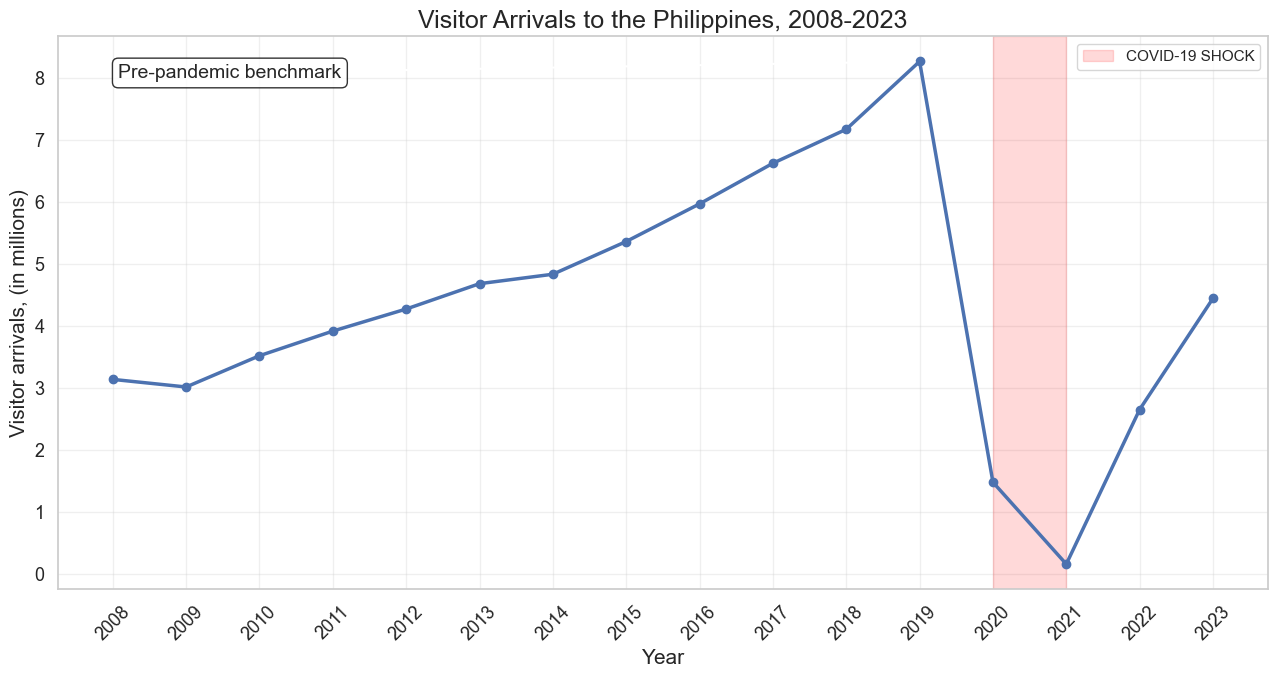

In [152]:
# graph 1: Annual visitor arrivals

fig, ax = plt.subplots(figsize=(13,7))
ax.plot(
    annual_df["year"],
    annual_df["visitors_arrivals_millions"],
    marker="o",
    linewidth=2.5
)

ax.axvspan(2020, 2021, alpha=0.15, color="red", label="COVID-19 SHOCK")

ax.set_title("Visitor Arrivals to the Philippines, 2008-2023")
ax.set_xlabel("Year")
ax.set_ylabel("Visitor arrivals, (in millions)")
ax.set_xticks(annual_df["year"])
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

if 2019 in annual_df["year"].values:
    y2019 = annual_df.loc[annual_df["year"] == 2019, "visitors_arrivals_millions"].iloc[0]
    ax.annotate(
        "Pre-pandemic benchmark",
        xy=(2019, y2019),
        xytext=(0.05, 0.95),
        textcoords="axes fraction",
        arrowprops=dict(arrowstyle='->', lw=1.5),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8),
        ha="left",
        va="top",
        clip_on=False
    )

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "fig1_annual_visitor_arrivals.png", dpi=300, bbox_inches="tight")
plt.show()


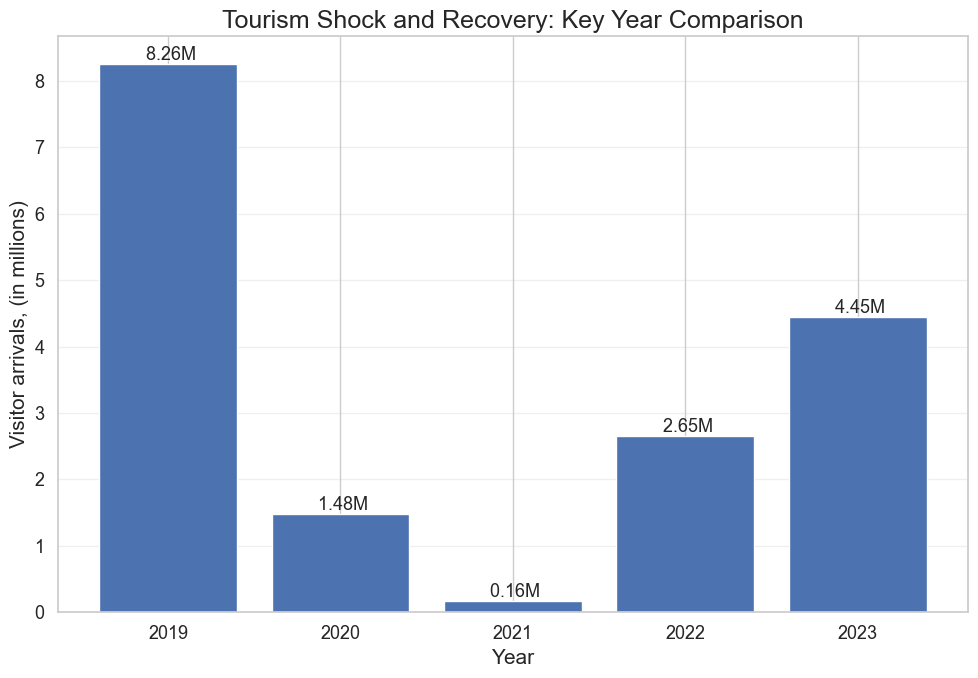

In [139]:
# graph 2: Key Year Comparison

key_years =[2019, 2020, 2021, 2022, 2023]
key_df = annual_df[annual_df["year"].isin(key_years)].copy()

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(key_df["year"].astype(str), key_df["visitors_arrivals_millions"])

ax.set_title("Tourism Shock and Recovery: Key Year Comparison")
ax.set_xlabel("Year")
ax.set_ylabel("Visitor arrivals, (in millions)")

for bar, value in zip(bars, key_df["visitors_arrivals_millions"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value: .2f}M",
        ha="center",
        va="bottom",
        fontsize=13
    )

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "fig2_key_year_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

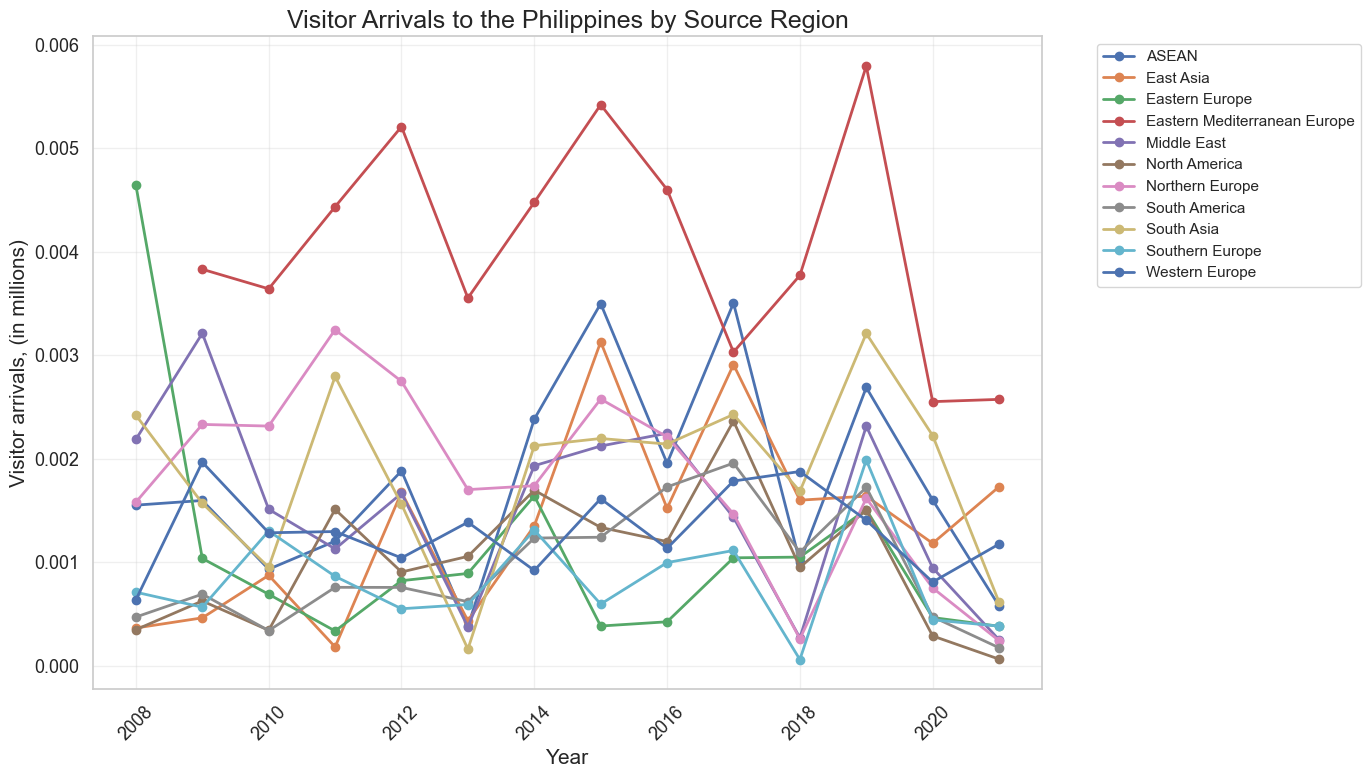

In [140]:
# graph 3: regional viistor arrivals over time

plot_region = region_year.copy()
plot_region["arrivals_millions"] = plot_region["region_arrivals"] / 1_000_000

fig, ax = plt.subplots(figsize=(14, 8))

for region in sorted(plot_region["region"].dropna().unique()):
    temp = plot_region[plot_region["region"] == region]

    ax.plot(
        temp["year"],
        temp["arrivals_millions"],
        marker="o",
        linewidth=2,
        label=region
    )

ax.set_title("Visitor Arrivals to the Philippines by Source Region")
ax.set_xlabel("Year")
ax.set_ylabel("Visitor arrivals, (in millions)")
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "fig3_region_arrivals_over_time.png", dpi=300, bbox_inches="tight")
plt.show()


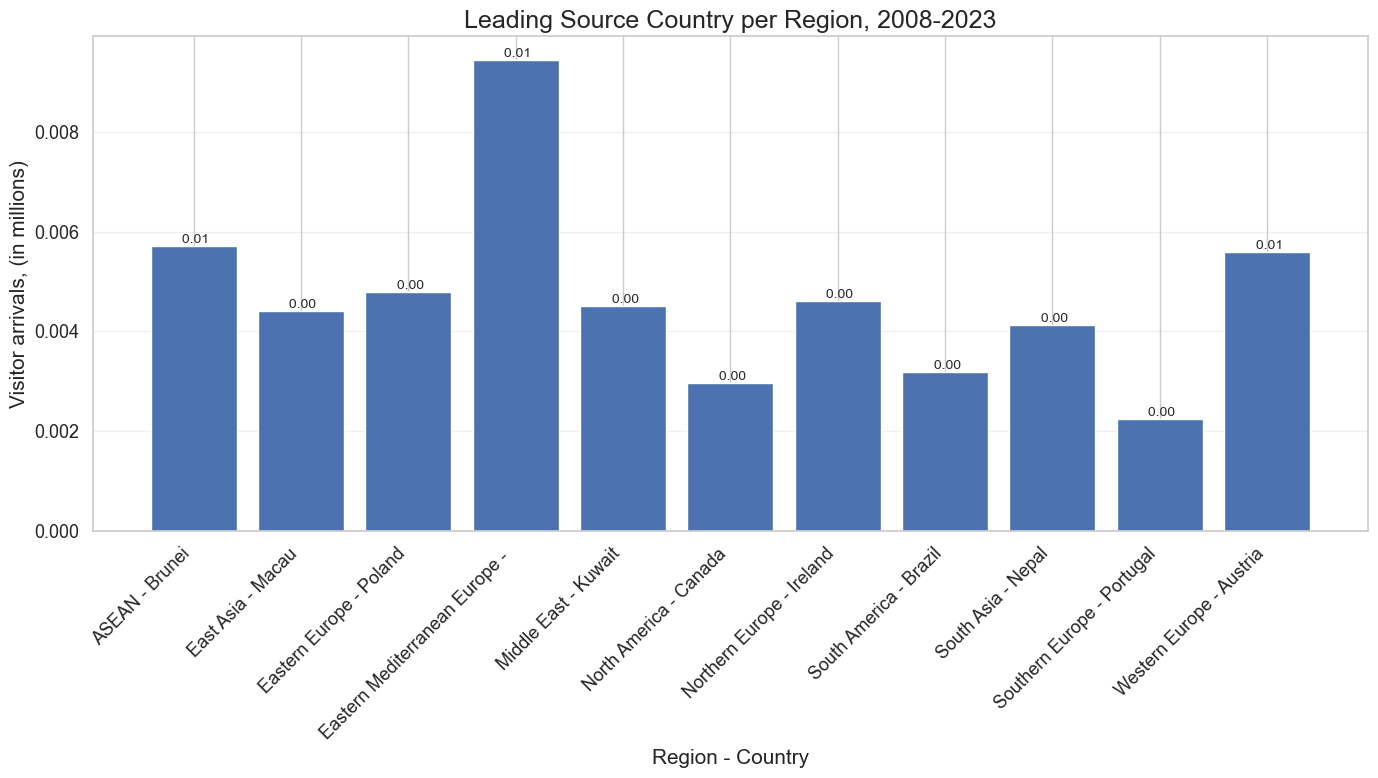

In [151]:
# graph 4: top source country per region using the multi-index pivot table

country_region_totals = (
    country_region_pivot
    .fillna(0)
    .sum(axis=1)
    .rename("total_arrivals")
    .reset_index()
)

invalid_country_pattern = r"\b(?:sub|total|others|unspecified|overseas|philippines)\b"
country_region_totals = country_region_totals[
    ~country_region_totals["country"].str.contains(invalid_country_pattern, case=False, na=False)
]

region_top_country = (
    country_region_totals
    .sort_values(["region", "total_arrivals"], ascending=[True, False])
    .groupby("region", as_index=False)
    .first()
)

region_top_country["total_arrivals_millions"] = region_top_country["total_arrivals"] / 1_000_000

fig, ax = plt.subplots(figsize=(14, 8))

x_labels = region_top_country["region"] + " - " + region_top_country["country"]
values = region_top_country["total_arrivals_millions"]

ax.bar(x_labels, values)

ax.set_title("Leading Source Country per Region, 2008-2023")
ax.set_xlabel("Region - Country")
ax.set_ylabel("Visitor arrivals, (in millions)")
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45, ha="right")

for i, value in enumerate(values):
    ax.text(i, value, f"{value: .2f}", ha="center", va="bottom", fontsize=10)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "fig4_top_country_per_region_overall.png", dpi=300, bbox_inches="tight")
plt.show()


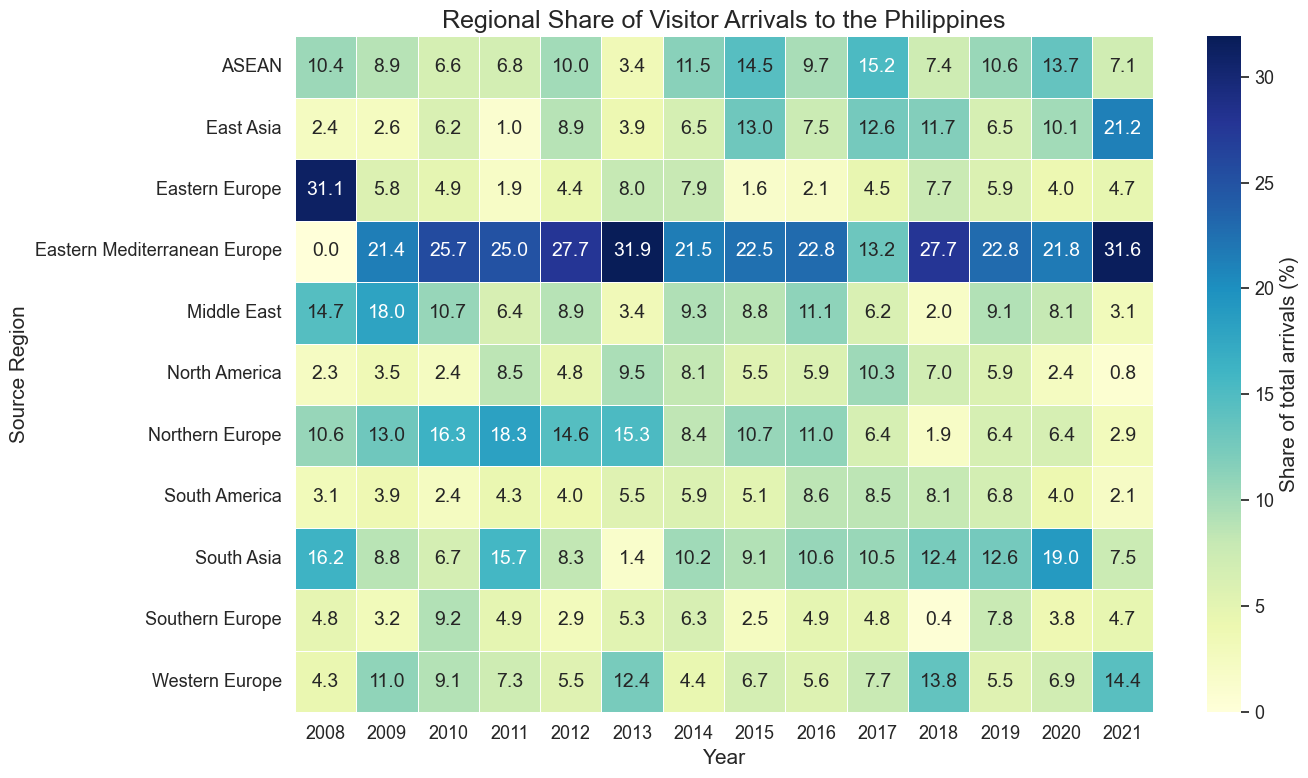

In [143]:
# graph 5: regional share heatmap

region_share_pivot = pd.pivot_table(
    region_share_df,
    index="region",
    columns="year",
    values="region_share_pct",
    aggfunc="sum",
    fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    region_share_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Share of total arrivals (%)"},
    ax=ax
)

ax.set_title("Regional Share of Visitor Arrivals to the Philippines")
ax.set_xlabel("Year")
ax.set_ylabel("Source Region")

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "fig5_region_share_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


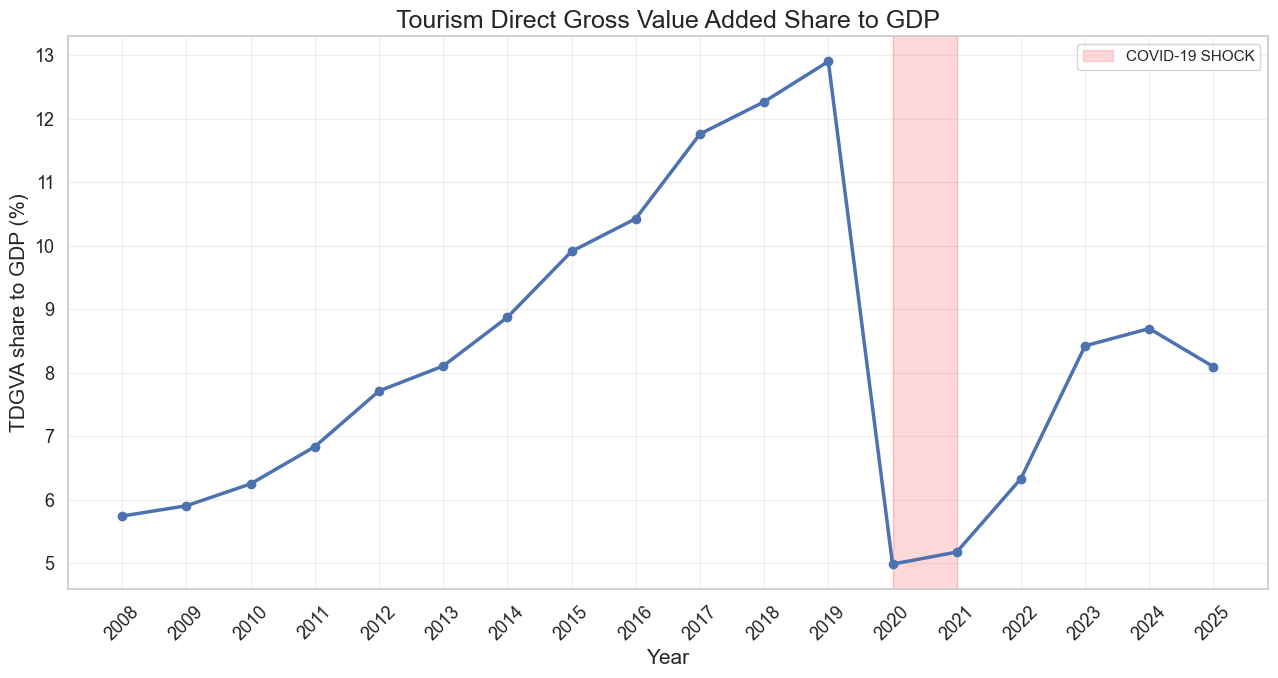

In [144]:
# graph 6: tourism share of gdp to the Philippines

if not ptsa_tdgva.empty:
    fig, ax = plt.subplots(figsize=(13, 7))

    ax.plot(
        ptsa_tdgva["year"],
        ptsa_tdgva["tdgva_share_to_gdp_pct"],
        marker="o",
        linewidth=2.5
    )

    ax.axvspan(2020, 2021, alpha=0.15, color="red", label="COVID-19 SHOCK")

    ax.set_title("Tourism Direct Gross Value Added Share to GDP")
    ax.set_xlabel("Year")
    ax.set_ylabel("TDGVA share to GDP (%)")
    ax.set_xticks(ptsa_tdgva["year"])
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_FOLDER / "fig6_tdgva_share_to_gdp.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("PTSA data not available, skipping Graph 6.")

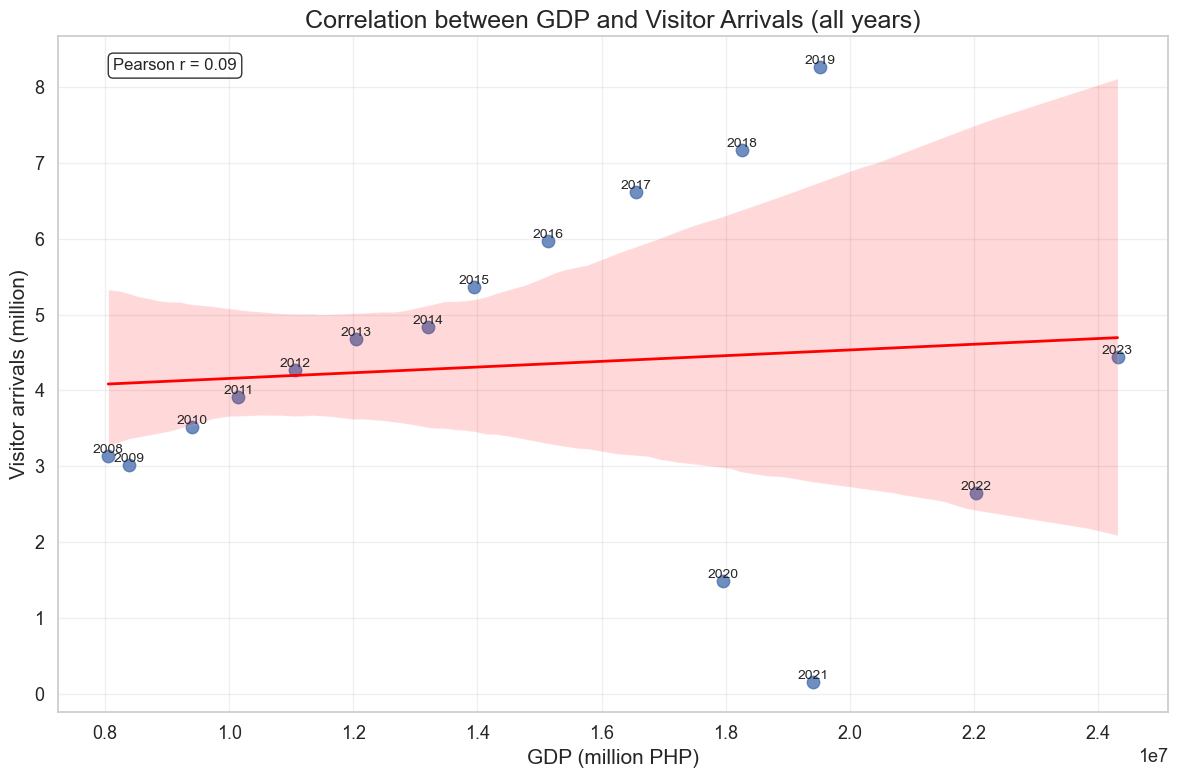

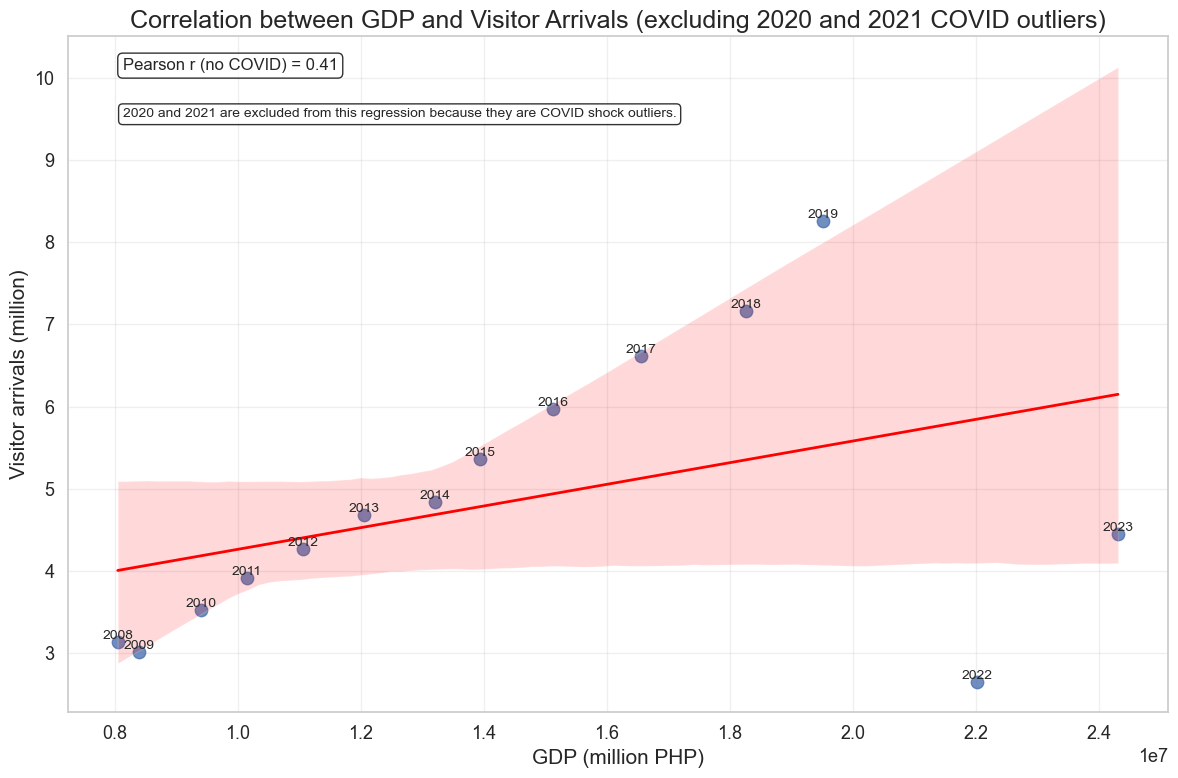

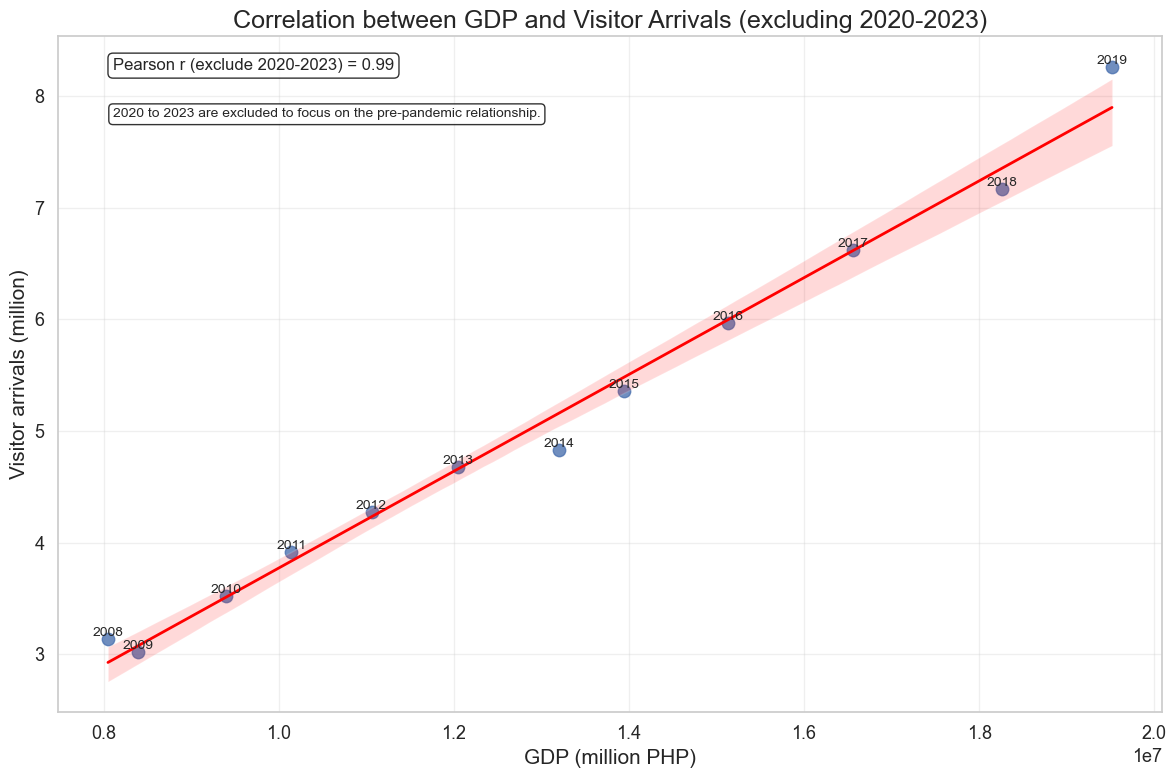

In [155]:
# graph 7: GDP vs Visitor Arrivals correlation
if not ptsa_tdgva.empty:
    merged_gdp = (
        annual_df[["year", "visitors_arrivals"]]
        .merge(ptsa_tdgva[["year", "gdp_million_php"]], on="year", how="inner")
    )
    merged_gdp["visitors_arrivals_millions"] = merged_gdp["visitors_arrivals"] / 1_000_000

    if not merged_gdp.empty:
        # plot with all years included
        correlation = merged_gdp["gdp_million_php"].corr(merged_gdp["visitors_arrivals_millions"])
        fig, ax = plt.subplots(figsize=(12, 8))

        sns.regplot(
            data=merged_gdp,
            x="gdp_million_php",
            y="visitors_arrivals_millions",
            scatter_kws={"s": 80, "alpha": 0.8},
            line_kws={"color": "red", "lw": 2},
            ax=ax
        )

        for _, row in merged_gdp.iterrows():
            ax.text(
                row["gdp_million_php"],
                row["visitors_arrivals_millions"],
                int(row["year"]),
                fontsize=10,
                ha="center",
                va="bottom"
            )

        ax.set_title("Correlation between GDP and Visitor Arrivals (all years)")
        ax.set_xlabel("GDP (million PHP)")
        ax.set_ylabel("Visitor arrivals (million)")
        ax.grid(True, alpha=0.3)

        ax.text(
            0.05,
            0.95,
            f"Pearson r = {correlation:.2f}",
            transform=ax.transAxes,
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
        )

        plt.tight_layout()
        plt.savefig(OUTPUT_FOLDER / "fig7_gdp_arrivals_correlation_all_years.png", dpi=300, bbox_inches="tight")
        plt.show()

        # plot excluding COVID outlier years (2020 and 2021)
        covid_years = [2020, 2021]
        merged_gdp_no_covid = merged_gdp[~merged_gdp["year"].isin(covid_years)]

        if not merged_gdp_no_covid.empty:
            correlation_no_covid = merged_gdp_no_covid["gdp_million_php"].corr(
                merged_gdp_no_covid["visitors_arrivals_millions"]
            )
            fig, ax = plt.subplots(figsize=(12, 8))

            sns.regplot(
                data=merged_gdp_no_covid,
                x="gdp_million_php",
                y="visitors_arrivals_millions",
                scatter_kws={"s": 80, "alpha": 0.8},
                line_kws={"color": "red", "lw": 2},
                ax=ax
            )

            for _, row in merged_gdp_no_covid.iterrows():
                ax.text(
                    row["gdp_million_php"],
                    row["visitors_arrivals_millions"],
                    int(row["year"]),
                    fontsize=10,
                    ha="center",
                    va="bottom"
                )

            ax.set_title("Correlation between GDP and Visitor Arrivals (excluding 2020 and 2021 COVID outliers)")
            ax.set_xlabel("GDP (million PHP)")
            ax.set_ylabel("Visitor arrivals (million)")
            ax.grid(True, alpha=0.3)

            ax.text(
                0.05,
                0.95,
                f"Pearson r (no COVID) = {correlation_no_covid:.2f}",
                transform=ax.transAxes,
                fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
            )

            ax.text(
                0.05,
                0.88,
                "2020 and 2021 are excluded from this regression because they are COVID shock outliers.",
                transform=ax.transAxes,
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
            )

            plt.tight_layout()
            plt.savefig(OUTPUT_FOLDER / "fig7_gdp_arrivals_correlation_no_covid.png", dpi=300, bbox_inches="tight")
            plt.show()
        else:
            print("No non-COVID data points available for the exclusion plot.")

        # plot excluding 2020 to 2023
        excluded_years = [2020, 2021, 2022, 2023]
        merged_gdp_pre_2020 = merged_gdp[~merged_gdp["year"].isin(excluded_years)]

        if not merged_gdp_pre_2020.empty:
            correlation_pre_2020 = merged_gdp_pre_2020["gdp_million_php"].corr(
                merged_gdp_pre_2020["visitors_arrivals_millions"]
            )
            fig, ax = plt.subplots(figsize=(12, 8))

            sns.regplot(
                data=merged_gdp_pre_2020,
                x="gdp_million_php",
                y="visitors_arrivals_millions",
                scatter_kws={"s": 80, "alpha": 0.8},
                line_kws={"color": "red", "lw": 2},
                ax=ax
            )

            for _, row in merged_gdp_pre_2020.iterrows():
                ax.text(
                    row["gdp_million_php"],
                    row["visitors_arrivals_millions"],
                    int(row["year"]),
                    fontsize=10,
                    ha="center",
                    va="bottom"
                )

            ax.set_title("Correlation between GDP and Visitor Arrivals (excluding 2020-2023)")
            ax.set_xlabel("GDP (million PHP)")
            ax.set_ylabel("Visitor arrivals (million)")
            ax.grid(True, alpha=0.3)

            ax.text(
                0.05,
                0.95,
                f"Pearson r (exclude 2020-2023) = {correlation_pre_2020:.2f}",
                transform=ax.transAxes,
                fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
            )

            ax.text(
                0.05,
                0.88,
                "2020 to 2023 are excluded to focus on the pre-pandemic relationship.",
                transform=ax.transAxes,
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
            )

            plt.tight_layout()
            plt.savefig(OUTPUT_FOLDER / "fig8_gdp_arrivals_correlation_excluding_2020_2023.png", dpi=300, bbox_inches="tight")
            plt.show()
        else:
            print("No data points available after excluding 2020-2023.")
    else:
        print("No matching GDP and arrivals data available for correlation plot.")
else:
    print("PTSA data not available, skipping GDP-arrivals correlation plot.")